# Figure 5: Cold-Cloud Metrics vs. Time-to-Impact

**Three-panel layout**
- **(a)** Cold-cloud-top area (BT < 208 K, ×10⁶ km²): answers **Q3**  
- **(b)** CDO area (BT < 235 K, ×10⁶ km²): answers **Q4**  
- **(c)** Minimum BT (K): coldest cloud top

Solid lines = WNP typhoons | Dashed = ATL hurricanes  
Dotted vertical lines = peak Vmax for each storm  

**Prerequisite**: `data/gridsat/metrics_{storm}.csv` (run `05_coldcloud_metrics.ipynb` first).

## 1: Setup

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from utils import (GRIDSAT_DIR, IBTRACS_DIR, FIG_DIR,
                   STORM_ORDER, STORMS, BT_COLD, BT_CDO, ensure_dirs)

ensure_dirs()
OUTPATH      = os.path.join(FIG_DIR, 'coldcloud_timeseries.png')
SMOOTH_WIN   = 3    # 3 × 3 h = 9-h rolling mean

## 2: Load metrics and track data

In [2]:
metrics = {}
tracks  = {}

for key in STORM_ORDER:
    m_path = os.path.join(GRIDSAT_DIR, f'metrics_{key}.csv')
    t_path = os.path.join(IBTRACS_DIR,  f'{key}_track.csv')

    if os.path.exists(m_path):
        df = pd.read_csv(m_path, parse_dates=['utc_time'])
        metrics[key] = df.sort_values('hours_to_impact')
        print(f'[{key}] {len(df)} metric rows loaded')
    else:
        print(f'[{key}] metrics CSV not found: run 05_coldcloud_metrics.ipynb first.')

    if os.path.exists(t_path):
        tracks[key] = pd.read_csv(t_path, parse_dates=['ISO_TIME'])

assert metrics, 'No metrics data found.'

[ragasa] 35 metric rows loaded
[mangkhut] 34 metric rows loaded
[maria] 34 metric rows loaded
[dorian] 34 metric rows loaded


## 3: Inspect peak CDO area per storm (Q4 quick table)

In [3]:
print(f'{"Storm":30s}  {"Basin":5s}  {"Max CDO area (×10⁶ km²)":>24s}  {"Min BT (K)":>10s}')
print('-' * 76)
for key in STORM_ORDER:
    df_m = metrics.get(key)
    if df_m is None:
        continue
    max_cdo  = df_m['cdo_area_km2'].max() / 1e6
    min_bt   = df_m['min_bt_K'].min()
    name     = f"{STORMS[key]['name']} ({STORMS[key]['year']})"
    print(f'{name:30s}  {STORMS[key]["basin"]:5s}  {max_cdo:24.2f}  {min_bt:10.1f}')

Storm                           Basin   Max CDO area (×10⁶ km²)  Min BT (K)
----------------------------------------------------------------------------
Ragasa (2025)                   WNP                        1.52       179.3
Mangkhut (2018)                 WNP                        1.74       184.1
Maria (2017)                    ATL                        0.87       185.4
Dorian (2019)                   ATL                        0.53       188.8


## 4: Plot Figure

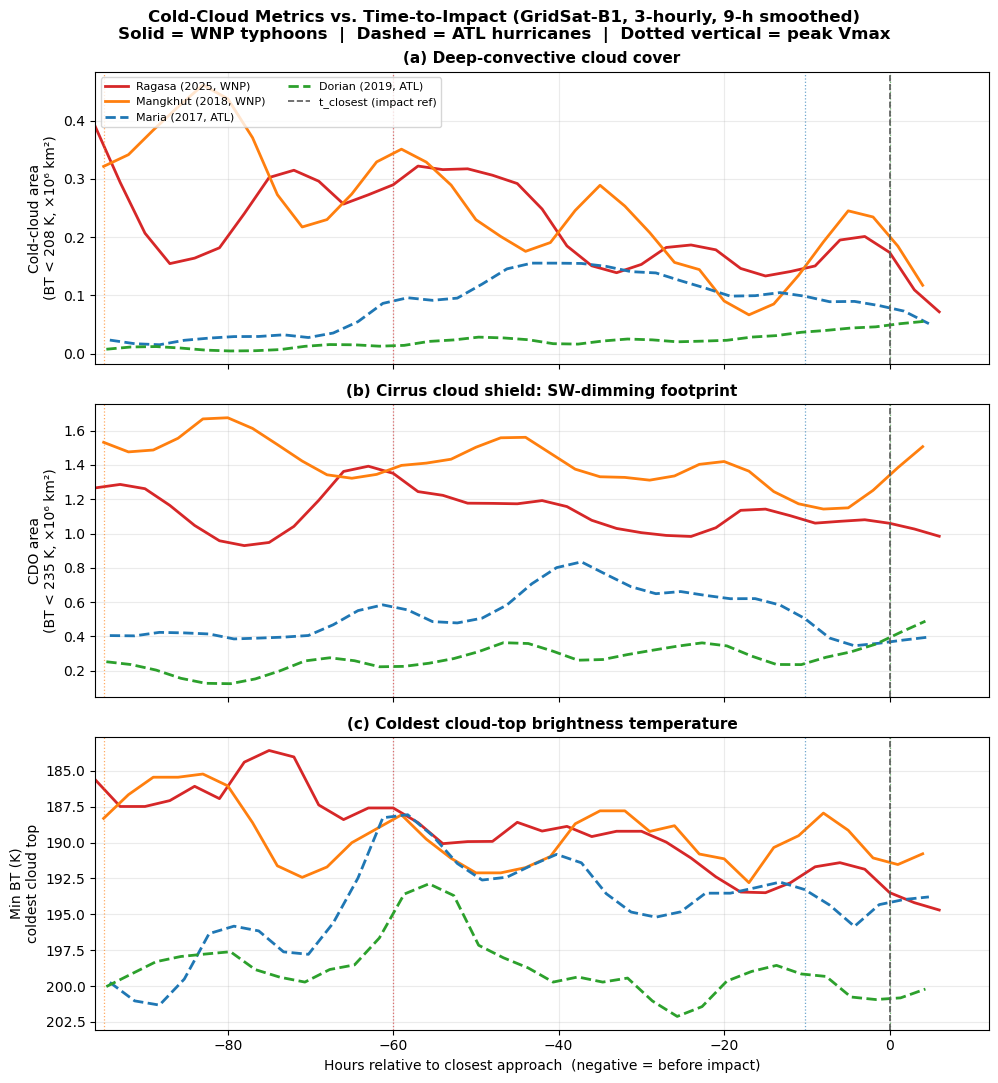

Saved → /home/sharperace/geog_1.02_final_proj/figures/coldcloud_timeseries.png


In [4]:
fig, axes = plt.subplots(3, 1, figsize=(10, 11), sharex=True)
ax_cold, ax_cdo, ax_bt = axes

for key in STORM_ORDER:
    df_m = metrics.get(key)
    trk  = tracks.get(key)
    if df_m is None:
        continue

    meta = STORMS[key]
    lbl  = f"{meta['name']} ({meta['year']}, {meta['basin']})"
    kw   = dict(color=meta['color'], linestyle=meta['linestyle'],
                linewidth=2, label=lbl)

    h     = df_m['hours_to_impact'].values
    cold  = uniform_filter1d(df_m['cold_area_km2'].values / 1e6, size=SMOOTH_WIN, mode='nearest')
    cdo   = uniform_filter1d(df_m['cdo_area_km2'].values  / 1e6, size=SMOOTH_WIN, mode='nearest')
    minbt = uniform_filter1d(df_m['min_bt_K'].values,             size=SMOOTH_WIN, mode='nearest')

    ax_cold.plot(h, cold,  **kw)
    ax_cdo.plot( h, cdo,   **kw)
    ax_bt.plot(  h, minbt, **kw)

    # Dotted vertical line at peak Vmax
    if trk is not None:
        h_pk = trk.loc[trk['USA_WIND'].idxmax(), 'hours_to_impact']
        for ax in axes:
            ax.axvline(h_pk, color=meta['color'], linestyle=':',
                       linewidth=0.9, alpha=0.65)

# Reference lines and formatting
for ax in axes:
    ax.axvline(0, color='0.35', linestyle='--', linewidth=1.2,
               label='t_closest (impact ref)')
    ax.set_xlim(-96, 12)
    ax.grid(alpha=0.25)

ax_cold.set_ylabel(f'Cold-cloud area\n(BT < {BT_COLD} K, ×10⁶ km²)', fontsize=10)
ax_cold.set_title('(a) Deep-convective cloud cover', fontsize=11, fontweight='bold')
ax_cold.legend(fontsize=8, loc='upper left', ncol=2)

ax_cdo.set_ylabel(f'CDO area\n(BT < {BT_CDO} K, ×10⁶ km²)', fontsize=10)
ax_cdo.set_title('(b) Cirrus cloud shield: SW-dimming footprint', fontsize=11, fontweight='bold')

ax_bt.set_ylabel('Min BT (K)\ncoldest cloud top', fontsize=10)
ax_bt.set_title('(c) Coldest cloud-top brightness temperature', fontsize=11, fontweight='bold')
ax_bt.invert_yaxis()   # lower BT = more intense → visually up
ax_bt.set_xlabel('Hours relative to closest approach  (negative = before impact)', fontsize=10)

fig.suptitle(
    'Cold-Cloud Metrics vs. Time-to-Impact (GridSat-B1, 3-hourly, 9-h smoothed)\n'
    'Solid = WNP typhoons  |  Dashed = ATL hurricanes  |  Dotted vertical = peak Vmax',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig(OUTPATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved → {OUTPATH}')